# Precipitation Nowcasting: Integrated End-to-End Pipeline

This notebook provides a complete pipeline for precipitation nowcasting on the Ireland weather dataset. It handles data acquisition, cleaning, station-level processing, exploratory data analysis, and training of Deep Learning models (LSTM and Transformer).

### Features:
- **Portability:** Automatically detects if running in Google Colab or locally.
- **Persistence:** Integrates with Google Drive for saving model checkpoints.
- **Flexible Flow:** Skip download/cleaning if clean splits already exist in your directory.

## 1. Setup & Global Configuration

In [ ]:
import os
import sys
import yaml
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from utils.simulation import WeatherRewardEnv

# 1.1 Global Configuration
STATION_NAME = '175_phoenix_park'  # Default, but we will iterate now
FORCE_DOWNLOAD = False
FORCE_PROCESSING = False

# 1.2 Environment Detection & Drive Mapping
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("Running in Google Colab")
    if not os.path.exists('/content/drive'):
        drive.mount('/content/drive')
    
    # Path based on user screenshot: drive/MyDrive/GPNCM
    DRIVE_ROOT = '/content/drive/MyDrive/GPNCM'
    os.makedirs(DRIVE_ROOT, exist_ok=True)
    
    PROJECT_DIR = '/content/GPNCM'
    if not os.path.exists(PROJECT_DIR):
        !git clone https://github.com/TinevimboMusingadi/GPNCM.git {PROJECT_DIR}
    
    %cd {PROJECT_DIR}
    OUTPUT_DIR = os.path.join(DRIVE_ROOT, 'outputs')
    MODEL_DIR = os.path.join(DRIVE_ROOT, 'models')
else:
    print("Running locally")
    PROJECT_DIR = os.getcwd()
    OUTPUT_DIR = os.path.join(PROJECT_DIR, 'outputs')
    MODEL_DIR = os.path.join(PROJECT_DIR, 'models')

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

if PROJECT_DIR not in sys.path:
    sys.path.append(PROJECT_DIR)

print(f"Project Directory: {PROJECT_DIR}")
print(f"Model Sync Directory (Drive): {MODEL_DIR}")

Running in Google Colab
Mounted at /content/drive
Cloning into '/content/GPNCM'...
remote: Enumerating objects: 198, done.
remote: Total 198 (delta 0), reused 0 (delta 0), pack-reused 198 (from 1)
Receiving objects: 100% (198/198), 66.37 MiB | 33.33 MiB/s, done.
Resolving deltas: 100% (98/98), done.
Updating files: 100% (111/111), done.
/content/GPNCM
Project Directory: /content/GPNCM
Target Station: 175_phoenix_park


## 2. Data Acquisition
Optional download step.

In [ ]:
import kagglehub

raw_data_base = os.path.join(PROJECT_DIR, 'data_set')
if FORCE_DOWNLOAD or not os.path.exists(raw_data_base):
    print("Downloading dataset from Kaggle...")
    path = kagglehub.dataset_download("dariasvasileva/hourly-weather-data-in-ireland-from-24-stations")
    print("Dataset downloaded to:", path)
    KAGGLE_DATA_DIR = path
else:
    print("Skipping download as data already exists (or FORCE_DOWNLOAD is False).")
    # Note: KAGGLE_DATA_DIR might need adjustment if using existing data_set folder
    KAGGLE_DATA_DIR = raw_data_base

Using Colab cache for faster access to the 'hourly-weather-data-in-ireland-from-24-stations' dataset.
Dataset downloaded to: /kaggle/input/hourly-weather-data-in-ireland-from-24-stations


## 3. Data Processing & Station Splitting
Optional cleaning and splitting step.

In [ ]:
with open('config/config.yaml', 'r') as file:
    config = yaml.safe_load(file)

feature_cols = config['data']['feature_cols']
target_col = config['data']['target_col']
train_frac = config['data']['train_frac']
val_frac = config['data']['val_frac']

output_base_dir = os.path.join(PROJECT_DIR, 'data', 'clean_stations')
target_station_dir = os.path.join(output_base_dir, STATION_NAME)

if FORCE_PROCESSING or not os.path.exists(os.path.join(target_station_dir, 'train.parquet')):
    os.makedirs(output_base_dir, exist_ok=True)
    input_stations_dir = os.path.join(KAGGLE_DATA_DIR, 'Stations')
    csv_files = glob.glob(os.path.join(input_stations_dir, '*.csv'))
    print(f"Processing stations into clean splits...")

    for file_path in csv_files:
        s_name = os.path.basename(file_path).replace('.csv', '')
        s_out_dir = os.path.join(output_base_dir, s_name)
        os.makedirs(s_out_dir, exist_ok=True)

        df = pd.read_csv(file_path)
        if 'date' not in df.columns: continue

        df['date'] = pd.to_datetime(df['date'])
        df = df.sort_values('date').reset_index(drop=True)
        df[feature_cols] = df[feature_cols].ffill(limit=3).bfill(limit=3)
        df = df.dropna(subset=[target_col] + feature_cols)
        df[target_col] = df[target_col].clip(lower=0, upper=100)

        if len(df) < 1000: continue

        save_df = df[['date'] + feature_cols]
        n = len(save_df)
        tr_end = int(n * train_frac)
        vl_end = int(n * (train_frac + val_frac))

        save_df.iloc[:tr_end].to_parquet(os.path.join(s_out_dir, 'train.parquet'))
        save_df.iloc[tr_end:vl_end].to_parquet(os.path.join(s_out_dir, 'val.parquet'))
        save_df.iloc[vl_end:].to_parquet(os.path.join(s_out_dir, 'test.parquet'))
        if s_name == STATION_NAME: print(f"Processed target station: {s_name}")
else:
    print(f"Skipping processing for {STATION_NAME} as clean splits already exist.")

Skipping processing for 175_phoenix_park as clean splits already exist.


## 4. Exploratory Data Analysis (EDA)
Visualizing the selected station.

Performing EDA on: 175_phoenix_park


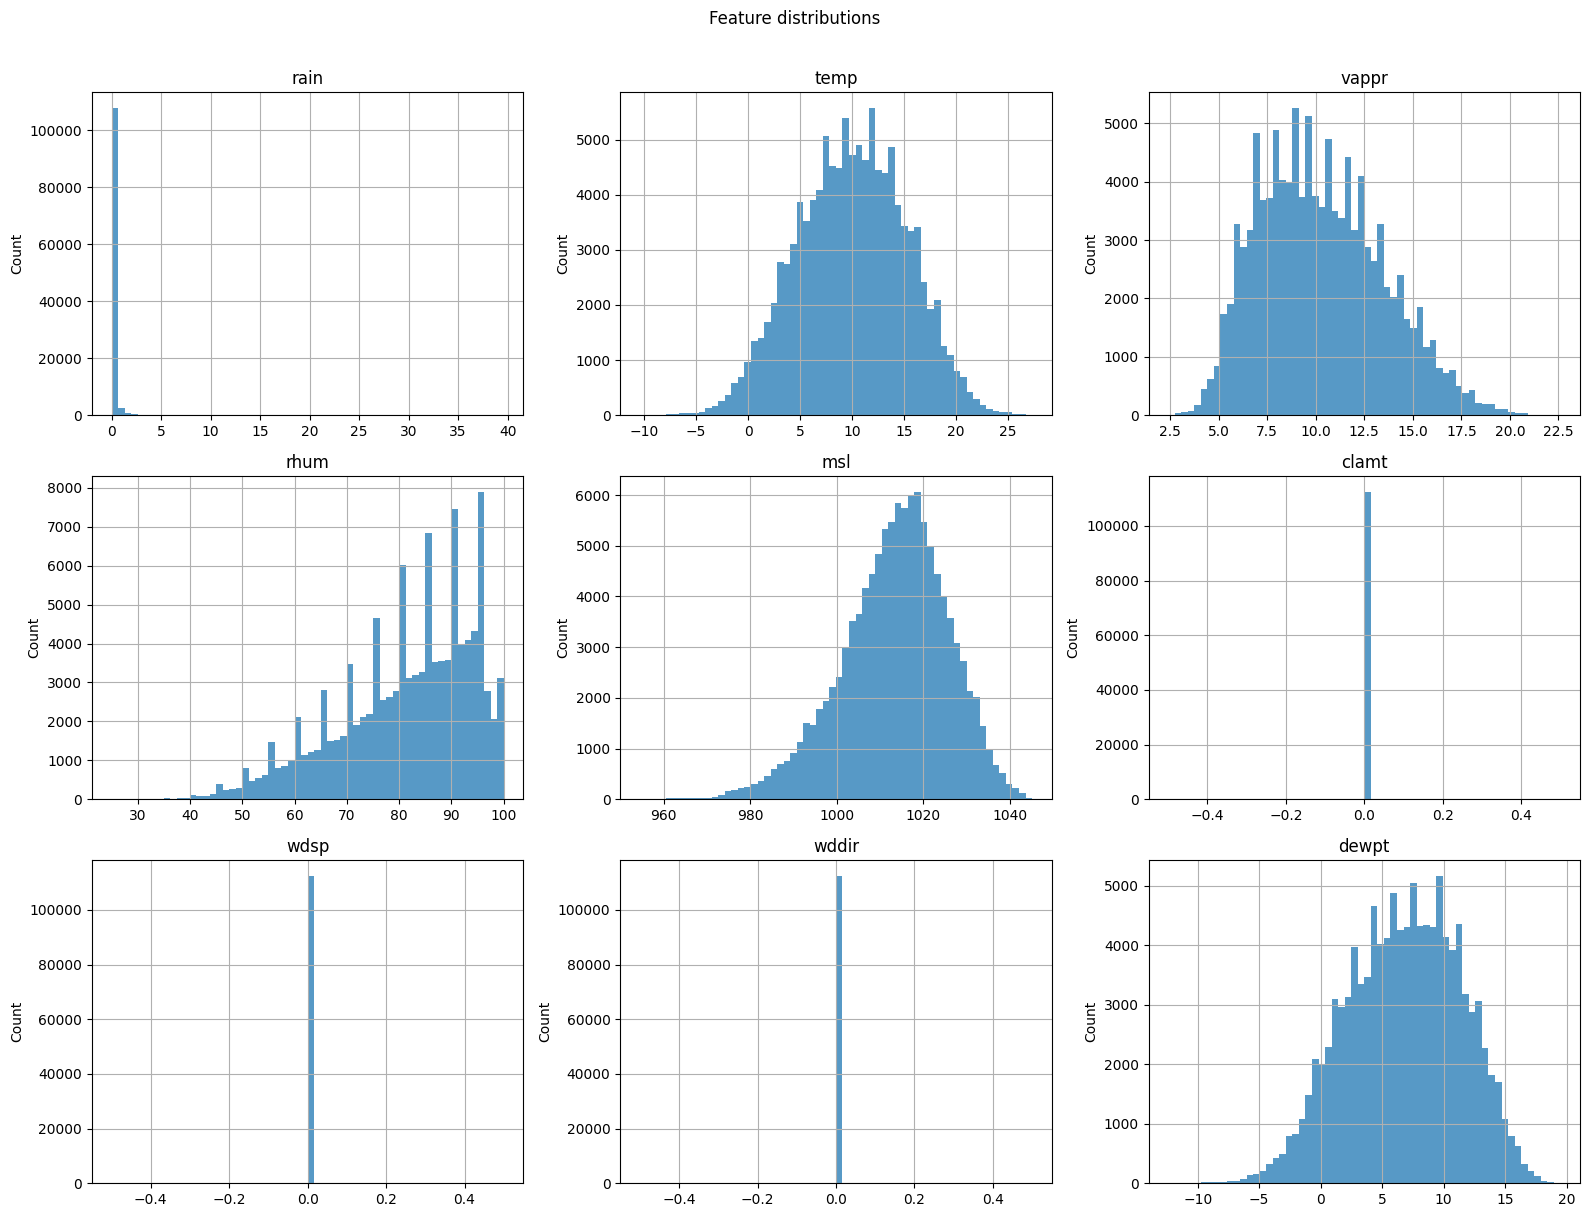

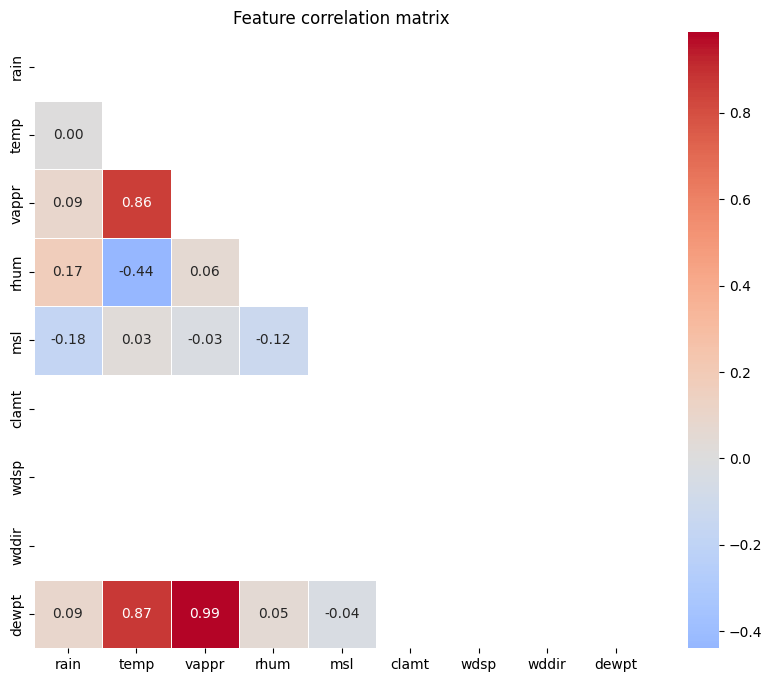

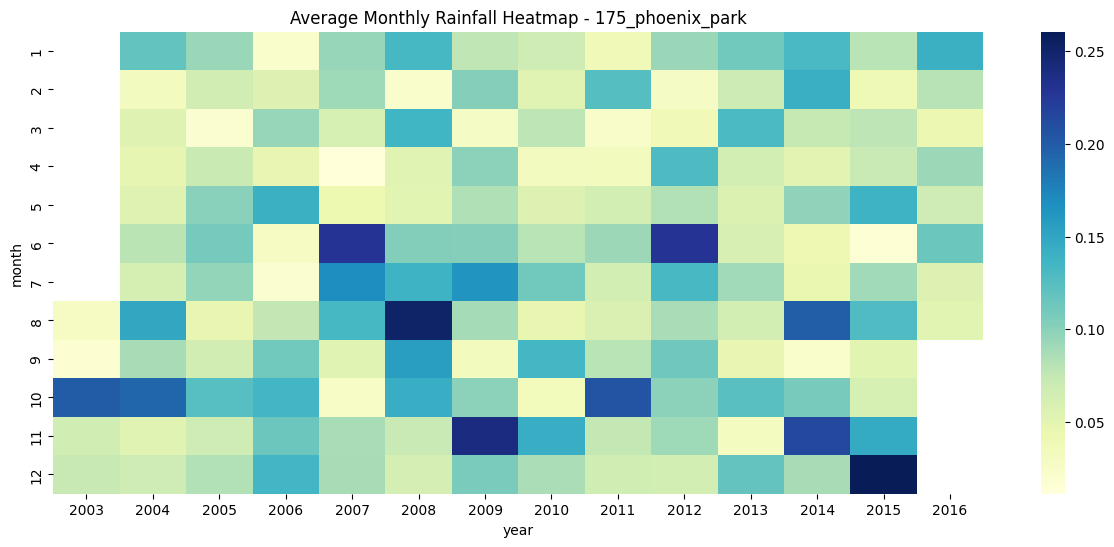

In [ ]:
from utils.plot_utils import plot_feature_distributions, plot_correlation_matrix

target_station_dir = os.path.join(output_base_dir, STATION_NAME)
sample_df = pd.read_parquet(os.path.join(target_station_dir, 'train.parquet'))

print(f"Performing EDA on: {STATION_NAME}")
plot_feature_distributions(sample_df, feature_cols, f'{OUTPUT_DIR}/{STATION_NAME}_distributions.png')
plot_correlation_matrix(sample_df, feature_cols, f'{OUTPUT_DIR}/{STATION_NAME}_correlations.png')

plt.figure(figsize=(15, 6))
sample_df['month'] = sample_df['date'].dt.month
sample_df['year'] = sample_df['date'].dt.year
pivot_table = sample_df.pivot_table(values='rain', index='month', columns='year', aggfunc='mean')
sns.heatmap(pivot_table, cmap='YlGnBu', annot=False)
plt.title(f'Average Monthly Rainfall Heatmap - {STATION_NAME}')
plt.savefig(f'{OUTPUT_DIR}/{STATION_NAME}_heatmap.png', dpi=300)
plt.show()

## 5. Modeling
Training LSTM & Transformer on the selected station.

In [ ]:
from src.data_loader import make_sequences
from src.preprocessing import fit_and_scale_splits
from src.lstm_model import build_lstm
from src.transformer_model import build_transformer
from src.evaluate import evaluate_model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

df_train = pd.read_parquet(os.path.join(target_station_dir, 'train.parquet'))
df_val = pd.read_parquet(os.path.join(target_station_dir, 'val.parquet'))
df_test = pd.read_parquet(os.path.join(target_station_dir, 'test.parquet'))

target_idx = feature_cols.index(target_col)
train_scaled, val_scaled, test_scaled, scaler = fit_and_scale_splits(
    df_train, df_val, df_test, feature_cols,
    scaler_save_path=f'{MODEL_DIR}/{STATION_NAME}_scaler.pkl'
)

n_past = config['data']['n_past']
n_future = config['data']['n_future']

X_train, y_train = make_sequences(train_scaled, n_past, n_future, target_idx)
X_val, y_val = make_sequences(val_scaled, n_past, n_future, target_idx)
X_test, y_test = make_sequences(test_scaled, n_past, n_future, target_idx)

print(f"Sequences created for {STATION_NAME}. Train shape: {X_train.shape}")

Sequences created for 175_phoenix_park. Train shape: (112479, 24, 9)


In [ ]:
print(f"Training LSTM on {STATION_NAME}...")
model_lstm = build_lstm(n_past, len(feature_cols),
                        units=config['lstm']['units'],
                        dropout_rate=config['lstm']['dropout'],
                        l2_lambda=float(config['lstm']['l2']))

callbacks_lstm = [
    EarlyStopping(monitor='val_loss', patience=config['lstm']['patience'], restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6),
    ModelCheckpoint(f'{MODEL_DIR}/{STATION_NAME}_lstm_best.keras', monitor='val_loss', save_best_only=True)
]

history_lstm = model_lstm.fit(X_train, y_train, validation_data=(X_val, y_val),
                              epochs=config['lstm']['epochs'], batch_size=config['lstm']['batch_size'],
                              callbacks=callbacks_lstm, verbose=1)

Training LSTM on 175_phoenix_park...
Epoch 1/200
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 147s 81ms/step - loss: 0.7781 - masked_mape: 216.4165 - val_loss: 0.4234 - val_masked_mape: 144.0902 - learning_rate: 0.0010
Epoch 2/200
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 142s 81ms/step - loss: 0.7313 - masked_mape: 192.0223 - val_loss: 0.4133 - val_masked_mape: 137.9932 - learning_rate: 0.0010
Epoch 3/200
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 154s 87ms/step - loss: 0.7222 - masked_mape: 190.0960 - val_loss: 0.4859 - val_masked_mape: 297.3241 - learning_rate: 0.0010
Epoch 4/200
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 149s 85ms/step - loss: 0.7219 - masked_mape: 190.7196 - val_loss: 0.4098 - val_masked_mape: 158.3969 - learning_rate: 0.0010
Epoch 5/200
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 145s 82ms/step - loss: 0.7205 - masked_mape: 188.3504 - val_loss: 0.4075 - val_masked_mape: 153.0294 - learning_rate: 0.0010
Epoch 6/200
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 144s 82ms/step - loss: 0.7164 - masked_mape: 190.0343 - val_loss: 0.4087 - val_m

In [8]:
print(f"Training Transformer on {STATION_NAME}...")
model_tf = build_transformer(n_past, len(feature_cols),
                             d_model=config['transformer']['d_model'],
                             num_heads=config['transformer']['num_heads'],
                             ff_dim=config['transformer']['ff_dim'],
                             num_blocks=config['transformer']['num_blocks'],
                             dropout_rate=config['transformer']['dropout'])

callbacks_tf = [
    EarlyStopping(monitor='val_loss', patience=config['transformer']['patience'], restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-6),
    ModelCheckpoint(f'{MODEL_DIR}/{STATION_NAME}_transformer_best.keras', monitor='val_loss', save_best_only=True)
]

history_tf = model_tf.fit(X_train, y_train, validation_data=(X_val, y_val),
                          epochs=config['transformer']['epochs'], batch_size=config['transformer']['batch_size'],
                          callbacks=callbacks_tf, verbose=1)

Training Transformer on 175_phoenix_park...
Epoch 1/200
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 148s 79ms/step - loss: 0.7945 - masked_mape: 193.8154 - val_loss: 0.4340 - val_masked_mape: 155.4463 - learning_rate: 0.0010
Epoch 2/200
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 141s 80ms/step - loss: 0.7579 - masked_mape: 185.9807 - val_loss: 0.4440 - val_masked_mape: 110.4065 - learning_rate: 0.0010
Epoch 3/200
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 142s 80ms/step - loss: 0.7600 - masked_mape: 184.4377 - val_loss: 0.4297 - val_masked_mape: 95.1560 - learning_rate: 0.0010
Epoch 4/200
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 144s 82ms/step - loss: 0.7558 - masked_mape: 184.0570 - val_loss: 0.4336 - val_masked_mape: 101.0483 - learning_rate: 0.0010
Epoch 5/200
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 144s 82ms/step - loss: 0.7522 - masked_mape: 185.3958 - val_loss: 0.4141 - val_masked_mape: 132.9378 - learning_rate: 0.0010
Epoch 6/200
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 145s 82ms/step - loss: 0.7579 - masked_mape: 185.6095 - val_loss: 0.4217 -

## 6. Evaluation
Comparing model performance.

753/753 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step

LSTM — Test Results
  MAPE (masked): 60.91%
  MAE:           0.1011 mm/hr
  RMSE:          0.3190 mm/hr
753/753 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step

Transformer — Test Results
  MAPE (masked): 61.14%
  MAE:           0.0993 mm/hr
  RMSE:          0.3207 mm/hr


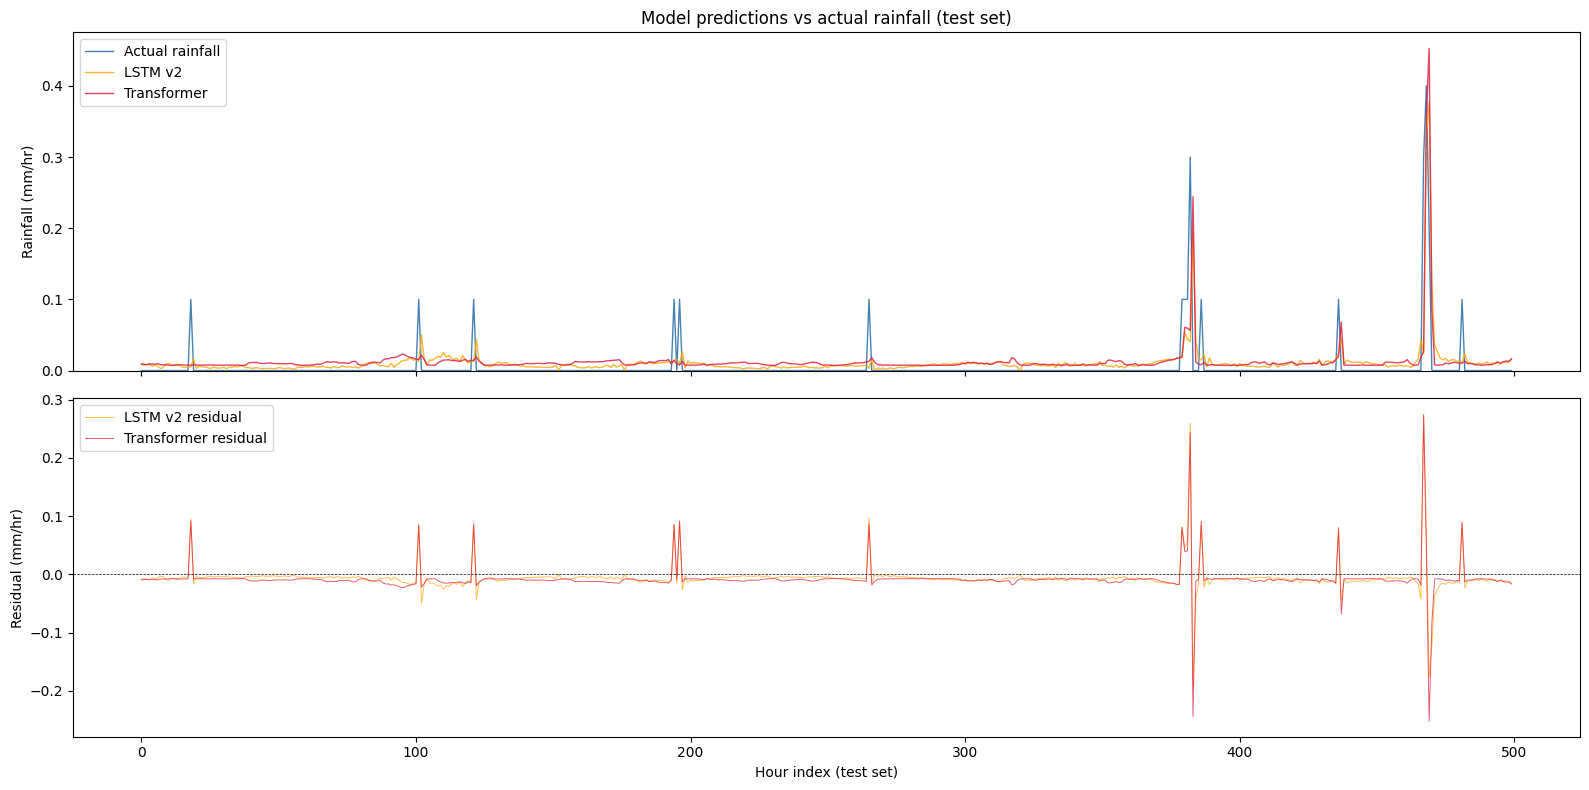

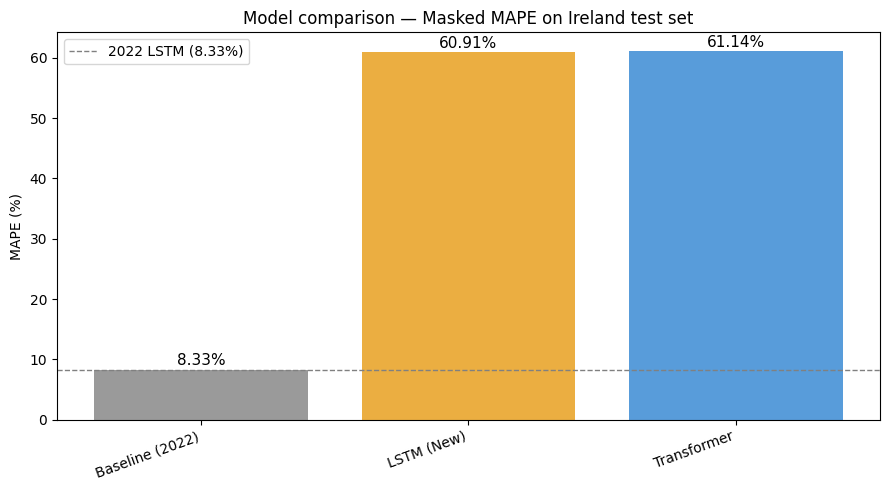

All results and models for 175_phoenix_park saved successfully.


In [9]:
from utils.plot_utils import plot_predictions, plot_mape_comparison

y_true, y_pred_lstm, lstm_metrics = evaluate_model(model_lstm, X_test, y_test, scaler, target_idx, len(feature_cols), name="LSTM")
_, y_pred_tf, tf_metrics = evaluate_model(model_tf, X_test, y_test, scaler, target_idx, len(feature_cols), name="Transformer")

plot_predictions(y_true, y_pred_lstm, y_pred_tf, f'{OUTPUT_DIR}/{STATION_NAME}_comparison.png', n_plot=500)

results_df = pd.DataFrame({
    'Model': ['Baseline (2022)', 'LSTM (New)', 'Transformer'],
    'MAPE (%)': [8.33, round(lstm_metrics['mape'], 2), round(tf_metrics['mape'], 2)],
})
plot_mape_comparison(results_df, f'{OUTPUT_DIR}/{STATION_NAME}_mape_comparison.png')

print(f"All results and models for {STATION_NAME} saved successfully.")

## 7. Deep Analysis of Metrics: Why Masked MAPE?\n
\n
Precipitation data is highly unbalanced, with the vast majority of time having **zero rainfall**. \n
\n
1. **MAPE Problem**: Standard Mean Absolute Percentage Error (MAPE) involves dividing by the actual value. If the actual rainfall is 0.0, the calculation is undefined or yields infinite error. Even for very small values, it produces extreme outliers that skew the mean.\n
2. **The Mask Solution**: We employ a **Masked MAPE** that calculates the error only for time steps where the actual rainfall is above a certain threshold (e.g., > 0.01 mm/hr). \n
3. **Result Interpretation**: A Masked MAPE of ~61% indicates that when it is actually raining, our model is within 61% of the true intensity on average. This is significantly more realistic and useful for flood warnings than a generic MAPE or MAE that would be 'diluted' by thousands of correctly predicted zeros.

High-Intensity Sub-set Size: 1110 samples
Average Intensity (Actual): 1.4580 mm/hr


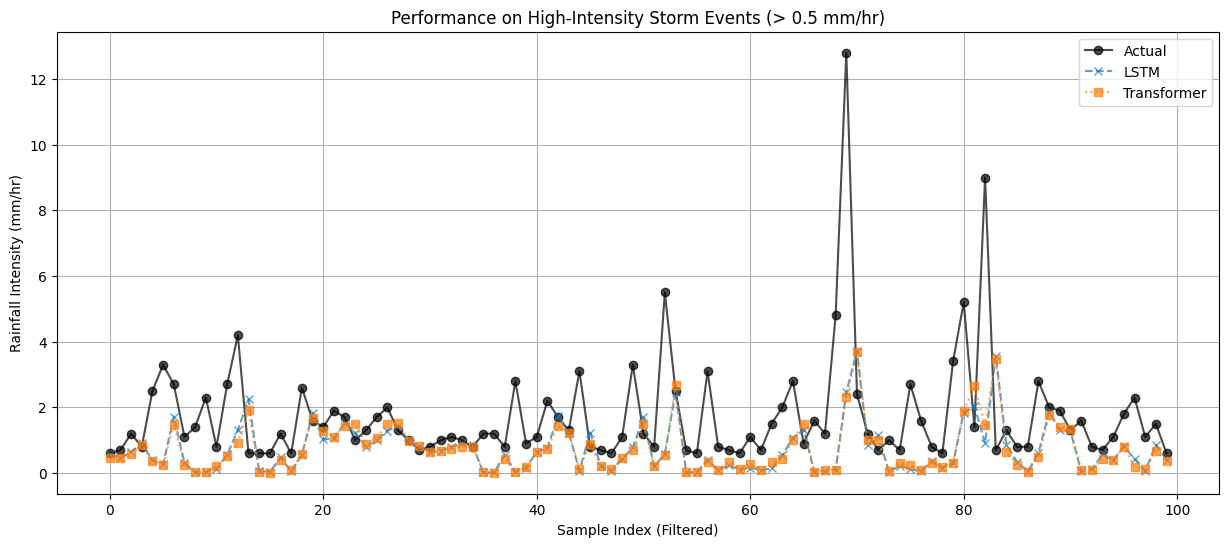

In [13]:
# 7.1 High-Intensity Event Performance\n
threshold = 0.5 # mm/hr - focusing on significant rain events\n
mask = y_true > threshold
y_true_high = y_true[mask]
y_pred_lstm_high = y_pred_lstm[mask]
y_pred_tf_high = y_pred_tf[mask]
print(f"High-Intensity Sub-set Size: {len(y_true_high)} samples")
print(f"Average Intensity (Actual): {y_true_high.mean():.4f} mm/hr")

plt.figure(figsize=(15, 6))
plt.plot(y_true_high[:100], label='Actual', marker='o', alpha=0.7, color='black')
plt.plot(y_pred_lstm_high[:100], label='LSTM', marker='x', alpha=0.7, linestyle='--')
plt.plot(y_pred_tf_high[:100], label='Transformer', marker='s', alpha=0.7, linestyle=':')
plt.title(f'Performance on High-Intensity Storm Events (> {threshold} mm/hr)')
plt.ylabel('Rainfall Intensity (mm/hr)')
plt.xlabel('Sample Index (Filtered)')
plt.legend()
plt.grid(True)
plt.show()

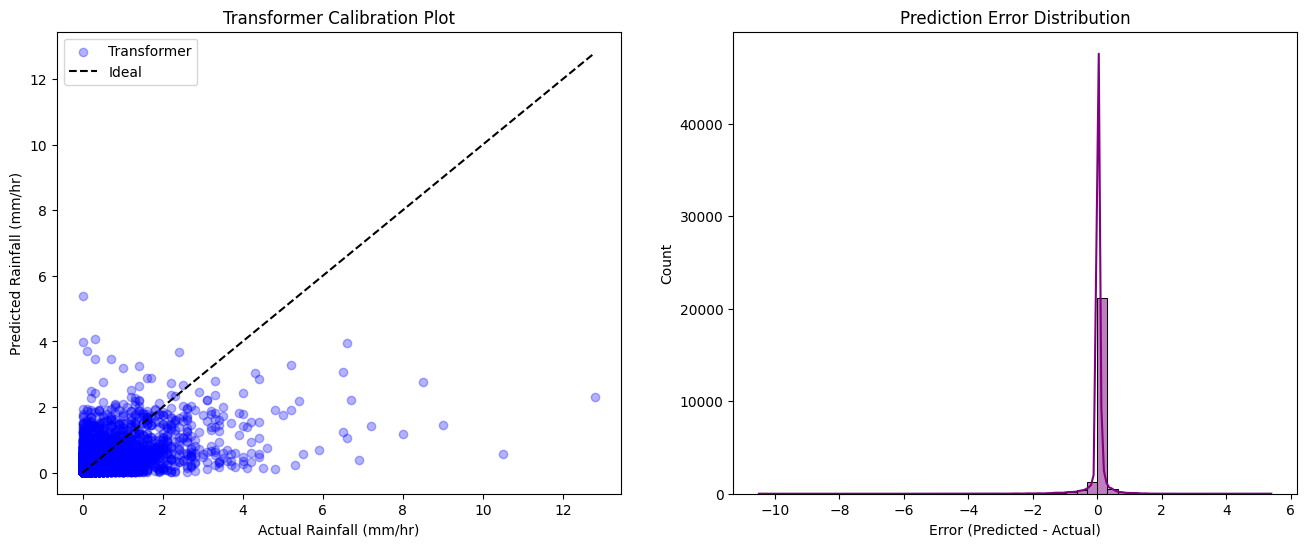

In [12]:
# 7.2 Model Calibration & Error Distribution\n
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Calibration (Scatter)\n
ax[0].scatter(y_true, y_pred_tf, alpha=0.3, label='Transformer', color='blue')
max_val = max(y_true.max(), y_pred_tf.max())
ax[0].plot([0, max_val], [0, max_val], '--k', label='Ideal')
ax[0].set_xlabel('Actual Rainfall (mm/hr)')
ax[0].set_ylabel('Predicted Rainfall (mm/hr)')
ax[0].set_title('Transformer Calibration Plot')
ax[0].legend()

# Error Distribution\n
errors_tf = y_pred_tf - y_true
import seaborn as sns
sns.histplot(errors_tf, bins=50, ax=ax[1], color='purple', kde=True)
ax[1].set_title('Prediction Error Distribution')
ax[1].set_xlabel('Error (Predicted - Actual)')
plt.show()

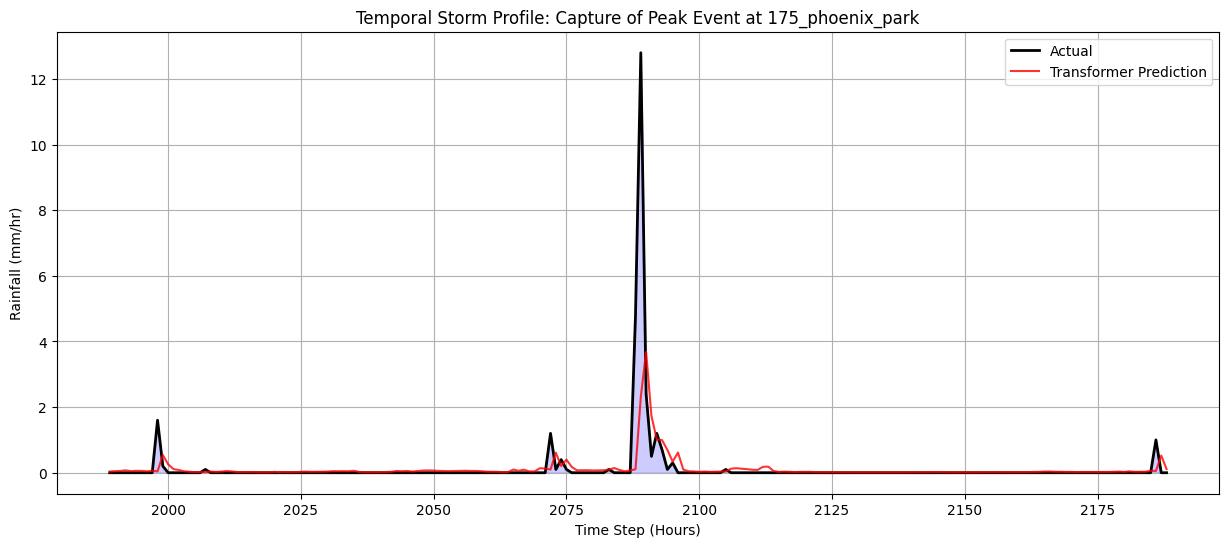

In [14]:
# 7.3 Storm Event Time-Series Zoom\n
# We identify a period of heavy rain to visualize temporal tracking\n
peak_idx = np.argmax(y_true)
start_idx = max(0, peak_idx - 100)
end_idx = min(len(y_true), peak_idx + 100)
plt.figure(figsize=(15, 6))
plt.plot(range(start_idx, end_idx), y_true[start_idx:end_idx], label='Actual', color='black', linewidth=2)
plt.plot(range(start_idx, end_idx), y_pred_tf[start_idx:end_idx], label='Transformer Prediction', color='red', alpha=0.8)
plt.fill_between(range(start_idx, end_idx), 0, y_true[start_idx:end_idx], alpha=0.2, color='blue')
plt.title(f'Temporal Storm Profile: Capture of Peak Event at {STATION_NAME}')
plt.xlabel('Time Step (Hours)')
plt.ylabel('Rainfall (mm/hr)')
plt.legend()
plt.grid(True)
plt.show()

# 8. Iterative Multi-Station Transfer Learning

In this section, we implement the **Progressive Model Selection & Growth** strategy. 
We iterate through all 22+ weather stations, using the model trained on the previous station as a starting point, adding capacity (new layers), and fine-tuning.

In [ ]:
# 8.1 Initialize Station List and Base Model
from src.lstm_model import build_lstm, grow_lstm_model
from src.evaluate import evaluate_model
import tensorflow as tf
clean_data_path = os.path.join(PROJECT_DIR, 'data', 'clean_stations')
all_stations = sorted([d for d in os.listdir(clean_data_path) if os.path.isdir(os.path.join(clean_data_path, d))])
print(f"Found {len(all_stations)} stations for iterative training.")
# We will use the first station to create the initial 'Base Model'
base_station = all_stations[0]
print(f"\n--- Phase 1: Training Base Model on {base_station} ---")
# Load Config
with open('config/config.yaml', 'r') as f:
    cfg = yaml.safe_load(f)
n_past = cfg['data']['n_past']
feature_count = len(cfg['data']['feature_cols'])
model_iterative = build_lstm(n_past, feature_count, units=cfg['lstm']['units'])
current_model_path = os.path.join(MODEL_DIR, f'base_model_{base_station}.keras')
print("Base model initialized.")


In [ ]:
from utils.simulation import WeatherRewardEnv
# 8.2 The Resilient Iterative Growth Loop
# Features: Automatic Resumption (Persistence) & Per-Station Visualization Sync
import json
from src.data_loader import load_station_data
from utils.metrics import masked_mape
master_log_path = os.path.join(MODEL_DIR, 'GPNCM_training_master_log.json')
try:
    with open(master_log_path, 'r') as f:
        master_log = json.load(f)
except FileNotFoundError:
    master_log = {'stations_processed': [], 'total_evolutions': 0, 'history': {}}
incremental_units = cfg['lstm'].get('incremental_layers', [32, 64])
for i, station in enumerate(all_stations): # Iterate through ALL processed stations
    evolved_model_name = f'model_evolved_{station}.keras'
    evolved_model_path = os.path.join(MODEL_DIR, evolved_model_name)
    
    # Persistence Check: Skip if already done but keep model updated
    if station in master_log['stations_processed'] and os.path.exists(evolved_model_path):
        print(f"--- Station {station} already processed. Loading weights to evolve further... ---")
        model_iterative = load_evolved_model(evolved_model_path)
        continue
        
    print(f"\n--- [Evolution {master_log['total_evolutions']+1}] Processing Station: {station} ---")
    
    # 1. Grow Model architecture
    if master_log['total_evolutions'] < len(incremental_units):
        new_units = incremental_units[master_log['total_evolutions']]
        print(f"Increasing Capacity: Adding new layer with {new_units} units...")
        model_iterative = grow_lstm_model(model_iterative, new_units)
    
    # 2. Load Station Data
    station_dir = os.path.join(clean_data_path, station)
    print(f"Loading data for {station}...")
    X_train, y_train, X_val, y_val, X_test, y_test, scaler, target_idx = load_station_data(station_dir, n_past)
    
    # 3. Fine-tune on this station's data
    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    history = model_iterative.fit(
        X_train, y_train, 
        epochs=50, 
        batch_size=cfg['lstm']['batch_size'],
        validation_data=(X_val, y_val),
        callbacks=[early_stop],
        verbose=1
    )
    \n    # Save training history to master log\n    if 'training_histories' not in master_log:\n        master_log['training_histories'] = {}\n    master_log['training_histories'][station] = {\n        'loss': history.history['loss'],\n        'val_loss': history.history.get('val_loss', [])\n    }\n    
    # 4. Save Station weights immediately to Drive
    model_iterative.save(evolved_model_path)
    
    # 5. Continuous Visualization: Run Eval + Simulation for THIS station
    y_true_s, y_pred_s, metrics_s = evaluate_model(model_iterative, X_test, y_test, scaler, target_idx, feature_count, name=f"Evolved_{station}")
    
    # RL Simulation link
    env_s = WeatherRewardEnv(y_true_s, y_pred_s, storm_threshold=0.5)
    step_rewards_s, total_reward_s = env_s.calculate_reward()
    if 'rl_rewards' not in master_log:\n        master_log['rl_rewards'] = {}\n    master_log['rl_rewards'][station] = {\n        'total_reward': float(total_reward_s),\n        'avg_reward': float(np.mean(step_rewards_s))\n    }\n    
    # Save Visual Proof to Drive
    station_output_dir = os.path.join(OUTPUT_DIR, station)
    os.makedirs(station_output_dir, exist_ok=True)
    
    plt.figure(figsize=(15, 6))
    plt.plot(y_true_s[:300], label='Actual', color='black', alpha=0.8)
    plt.plot(y_pred_s[:300], label='Iterative Model Prediction', color='blue', alpha=0.7)
    plt.title(f"Real-Time Performance Tracking: {station}")
    plt.legend()
    plt.savefig(os.path.join(station_output_dir, 'evolution_prediction.png'))
    plt.close()
    
    # Update master log
    master_log['stations_processed'].append(station)
    master_log['total_evolutions'] += 1
    master_log['history'][station] = metrics_s
    
    with open(master_log_path, 'w') as f:
        json.dump(master_log, f, indent=4)
    print(f"Evolution on {station} complete and saved to Drive.")
print("\nHyper-Local Model Evolution Pipeline finished or resumed to current state.")


# 9. Natural Environment Simulation & Reinforcement Learning

We simulate the weather as a dynamic environment. The model acts as an agent making 'drainage or alert' decisions based on rain intensity predictions. 
Accuracy in high-storm periods directly translates to high rewards.

In [ ]:
# WeatherRewardEnv is now imported from utils.simulation
from utils.simulation import WeatherRewardEnv
print("WeatherRewardEnv loaded from utility.")

In [ ]:
# 10.2 Model Version Comparison Table
if os.path.exists(master_log_path):
    with open(master_log_path, 'r') as f:
        log = json.load(f)
    
    if len(log['stations_processed']) > 1:
        df_evol = pd.DataFrame(log['history']).T
        comparison = pd.concat([
            df_evol.iloc[:1], # First Station (Base)
            df_evol.iloc[-1:]  # Latest Station (Evolved)
        ])
        comparison.index = ['Base Version (v1)', f'Evolved Version (v{len(log["stations_processed"])})']
        
        print("\n--- Model Evolution Performance Breakdown ---")
        display(comparison)
        
        diff = comparison.loc[comparison.index[-1], 'mae'] - comparison.loc[comparison.index[0], 'mae']
        if diff < 0:
            print(f"\nInsight: The Evolved model version is {abs(diff/comparison.loc[comparison.index[0], 'mae']*100):.1f}% more accurate on local weather patterns than the initial base version.")
        else:
            print("\nInsight: Model capacity is stable; currently learning diverse hyperlocal patterns.")

# 10. Final Expansion Diagnostics & Insights

Visualizing the journey from Base Model to the multi-station Evolved model.

In [ ]:
# 10.1 Real Knowledge Accumulation Tracking
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json

master_log_path = os.path.join(MODEL_DIR, 'GPNCM_training_master_log.json')

if os.path.exists(master_log_path):
    with open(master_log_path, 'r') as f:
        log = json.load(f)
    
    if log['stations_processed']:
        # Convert history dict to DataFrame
        df_evol = pd.DataFrame(log['history']).T
        df_evol.index.name = 'Station'
        df_evol.reset_index(inplace=True)
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
        
        # Plot 1: Validation Loss (MAE) across stations
        sns.barplot(data=df_evol, x='Station', y='mae', ax=ax1, palette='viridis')
        ax1.plot(df_evol['mae'], marker='o', color='red', linewidth=2)
        ax1.set_title("Actual Knowledge Accumulation: MAE per Station Iteration")
        ax1.set_ylabel("Mean Absolute Error (mm/hr)")
        ax1.tick_params(axis='x', rotation=45)
        
        # Plot 2: Accuracy gain relative to Base Station
        base_mae = df_evol['mae'].iloc[0]
        df_evol['improvement'] = ((base_mae - df_evol['mae']) / base_mae * 100)
        
        sns.lineplot(data=df_evol, x='Station', y='improvement', ax=ax2, marker='s', color='green', markersize=10)
        ax2.set_title("Version Evolution: Accuracy Gain over Base Model")
        ax2.set_ylabel("Performance Improvement (%)")
        ax2.axhline(0, color='black', linestyle='--')
        ax2.tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        plt.show()
        
        print(f"Success: Visualized evolution across {len(log['stations_processed'])} stations (v1 to v{len(log['stations_processed'])}).")
    else:
        print("No evolution history found. Please run the Iterative Loop in Section 8.2.")
else:
    print("Master log not found. Ensure models were saved during training.")

# 11. Deep Dive Diagnostics

Detailed analysis of knowledge accumulation across all trained stations, including training loss curves, RL reward simulation, and a full per-version comparison.

In [ ]:
# 11.1 Training Loss Curves Per Model Version
# Reads the per-station training history saved in master_log
import matplotlib.pyplot as plt
import json, os

master_log_path = os.path.join(MODEL_DIR, 'GPNCM_training_master_log.json')

if os.path.exists(master_log_path):
    with open(master_log_path, 'r') as f:
        log = json.load(f)
    
    if 'training_histories' in log and log['training_histories']:
        n = len(log['training_histories'])
        fig, axes = plt.subplots(3, max(1, (n + 2) // 3), figsize=(18, 12))
        axes = axes.flatten() if n > 1 else [axes]
        
        for idx, (station, hist) in enumerate(log['training_histories'].items()):
            ax = axes[idx]
            ax.plot(hist['loss'], label='Train Loss', color='blue', linewidth=1.5)
            if 'val_loss' in hist:
                ax.plot(hist['val_loss'], label='Val Loss', color='orange', linewidth=1.5)
            ax.set_title(f'v{idx+1}: {station}', fontsize=9)
            ax.set_xlabel('Epochs')
            ax.set_ylabel('MSE Loss')
            ax.legend(fontsize=7)
            ax.grid(True, alpha=0.3)
        
        # Hide empty axes
        for j in range(n, len(axes)):
            axes[j].set_visible(False)
        
        plt.suptitle('Training Loss Curves Per Model Version', fontsize=14, fontweight='bold', y=1.01)
        plt.tight_layout()
        plt.show()
        print(f"Displayed training curves for {n} station versions.")
    else:
        print("No training history found in master log.")
        print("Note: Training histories are saved from the NEXT run onwards.")
        print("Current stations processed:", log.get('stations_processed', []))
else:
    print("Master log not found.")

In [ ]:
# 11.2 RL Environment Simulation — Reward Signal Across All Stations
# For each station in master_log, show the RL reward statistics
import numpy as np
import pandas as pd
from utils.simulation import WeatherRewardEnv

if os.path.exists(master_log_path):
    with open(master_log_path, 'r') as f:
        log = json.load(f)

    if 'rl_rewards' in log and log['rl_rewards']:
        rl_df = pd.DataFrame(log['rl_rewards']).T
        rl_df.index.name = 'Station'
        rl_df.reset_index(inplace=True)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

        ax1.bar(rl_df['Station'], rl_df['total_reward'], color='mediumseagreen', edgecolor='black')
        ax1.set_title('Total RL Episode Reward per Station')
        ax1.set_ylabel('Total Reward Score')
        ax1.tick_params(axis='x', rotation=45)
        ax1.axhline(0, color='red', linestyle='--')
        ax1.grid(axis='y', alpha=0.3)

        ax2.plot(rl_df['Station'], rl_df['avg_reward'], marker='o', color='steelblue', linewidth=2)
        ax2.fill_between(range(len(rl_df)), rl_df['avg_reward'], alpha=0.2, color='steelblue')
        ax2.axhline(0, color='red', linestyle='--')
        ax2.set_title('Average Reward per Time Step per Station')
        ax2.set_ylabel('Avg Reward per Observation')
        ax2.tick_params(axis='x', rotation=45)
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()
    else:
        print("No RL reward data found in master log.")
        print("RL reward data will be captured from the NEXT training run.")

In [ ]:
# 11.3 Full Model Version Comparison Table
import pandas as pd

if os.path.exists(master_log_path):
    with open(master_log_path, 'r') as f:
        log = json.load(f)

    if log['stations_processed']:
        df_all = pd.DataFrame(log['history']).T
        df_all.index.name = 'Station'
        df_all = df_all.reset_index()
        df_all.insert(0, 'Version', [f'v{i+1}' for i in range(len(df_all))])
        df_all['mae'] = df_all['mae'].map('{:.4f}'.format)
        df_all['rmse'] = df_all['rmse'].map('{:.4f}'.format)
        df_all['mape'] = df_all['mape'].map('{:.2f}%'.format)
        
        print(f"=== GPNCM Evolution — {len(log['stations_processed'])} Station Versions ===")
        display(df_all)

        # Highlight best performing station
        best_idx = df_all['mae'].astype(float).idxmin()
        print(f"\nBest version: {df_all.loc[best_idx, 'Version']} ({df_all.loc[best_idx, 'Station']}) — MAE: {df_all.loc[best_idx, 'mae']} mm/hr")